# 05 - Model Evaluation

## Financial Portfolio Forecasting & Anomaly Detection

### Purpose

The goal of this notebook is to evaluate the final outputs of the project.

We will review:

- Forecasting model metrics
- Forecasting model comparison
- Best forecasting model
- Prediction accuracy
- Anomaly detection results
- Asset-wise anomaly behavior
- Final project insights
- Portfolio-ready summary


### Expected Project Outputs

This notebook can use outputs from:

```text
notebooks/03_forecasting_experiments.ipynb
notebooks/04_anomaly-detection_experiments.ipynb
scripts/run_all_models.py
scripts/evaluate_models.py
```

### Main Output Folders

- reports/tables/
- reports/figures/
- outputs/

## 1. Import Required Libraries

We import libraries for:

- Loading saved model results
- Evaluating forecasting metrics
- Evaluating anomaly detection outputs
- Creating final charts
- Saving final evaluation reports

In [37]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Define Project Paths

This notebook reads saved outputs from previous notebooks and training scripts.

Important folders:

```text
data/raw/
outputs/
reports/tables/
reports/figures/
models/

```

In [38]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "financial_portfolio_data.csv"

REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR = PROJECT_ROOT / "models"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data path:", RAW_DATA_PATH)
print("Raw data exists:", RAW_DATA_PATH.exists())

Project root: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection
Raw data path: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\data\raw\financial_portfolio_data.csv
Raw data exists: True


## 3. Helper Functions

We create helper functions to safely load CSV and JSON files.

This is useful because some files may exist only after running specific notebooks or scripts.

In [39]:
def load_csv_if_exists(file_path):
    """
    Load a CSV file if it exists.

    Args:
        file_path (Path): CSV file path.

    Returns:
        pd.DataFrame or None: Loaded dataframe or None.
    """
    file_path = Path(file_path)

    if not file_path.exists():
        print(f"File not found: {file_path}")
        return None

    try:
        dataframe = pd.read_csv(file_path)
        print(f"Loaded: {file_path}")
        print("Shape:", dataframe.shape)
        return dataframe

    except Exception as error:
        print(f"Failed to load {file_path}")
        print("Reason:", error)
        return None


def load_json_if_exists(file_path):
    """
    Load a JSON file if it exists.

    Args:
        file_path (Path): JSON file path.

    Returns:
        dict: Loaded JSON dictionary.
    """
    file_path = Path(file_path)

    if not file_path.exists():
        print(f"File not found: {file_path}")
        return {}

    try:
        with open(file_path, "r", encoding="utf-8") as file:
            data = json.load(file)

        print(f"Loaded: {file_path}")
        return data

    except Exception as error:
        print(f"Failed to load {file_path}")
        print("Reason:", error)
        return {}


def save_json(data, file_path):
    """
    Save dictionary as JSON.

    Args:
        data (dict): Data to save.
        file_path (Path): Output path.
    """
    file_path = Path(file_path)
    file_path.parent.mkdir(parents=True, exist_ok=True)

    with open(file_path, "w", encoding="utf-8") as file:
        json.dump(data, file, indent=4, default=str)

    print("Saved JSON:", file_path)


print("Helper functions created.")

Helper functions created.


## 4. Load Raw Dataset

We load the original financial portfolio dataset.

Expected columns:

```text
Date, Asset, Price

```

After cleaning, columns become:

```text
date, asset, price
```

In [40]:
raw_data = load_csv_if_exists(RAW_DATA_PATH)

if raw_data is not None:
    raw_data.columns = (
        raw_data.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )

    raw_data["date"] = pd.to_datetime(raw_data["date"], errors="coerce")
    raw_data["price"] = pd.to_numeric(raw_data["price"], errors="coerce")

    raw_data = raw_data.dropna(subset=["date", "asset", "price"])
    raw_data = raw_data[raw_data["price"] >= 0]
    raw_data = raw_data.sort_values(["asset", "date"]).reset_index(drop=True)

    print("Cleaned raw data shape:", raw_data.shape)
    display(raw_data.head())
else:
    raise FileNotFoundError(
        "Raw dataset is required for this evaluation notebook. "
        "Please place financial_portfolio_data.csv inside data/raw/."
    )

Loaded: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\data\raw\financial_portfolio_data.csv
Shape: (500, 3)
Cleaned raw data shape: (500, 3)


,date,asset,price
0,2023-01-03,Bond A,198.6100
1,2023-01-04,Bond A,142.2400
2,2023-01-08,Bond A,146.5800
3,2023-01-11,Bond A,473.2000
4,2023-01-13,Bond A,376.5700


## 5. Dataset Evaluation Summary

We summarize the dataset used for the final project evaluation.

In [41]:
dataset_summary = {
    "total_records": int(len(raw_data)),
    "total_assets": int(raw_data["asset"].nunique()),
    "assets": sorted(raw_data["asset"].unique().tolist()),
    "start_date": str(raw_data["date"].min()),
    "end_date": str(raw_data["date"].max()),
    "average_price": round(float(raw_data["price"].mean()), 4),
    "minimum_price": round(float(raw_data["price"].min()), 4),
    "maximum_price": round(float(raw_data["price"].max()), 4),
}

dataset_summary_df = pd.DataFrame([dataset_summary])
dataset_summary_df

,total_records,total_assets,assets,start_date,end_date,average_price,minimum_price,maximum_price
0,500,5,"[Bond A, Bond B, Commodity A, Stock A, Stock B]",2023-01-02 00:00:00,2023-12-31 00:00:00,281.3577,50.2000,499.7900


## 6. Load Forecasting Experiment Outputs

We first try to load outputs from notebook 03.

Important files:

```text
reports/tables/03_forecasting_model_comparison.csv
outputs/03_forecasting_predictions.csv
outputs/03_random_forest_future_forecast.csv
reports/tables/03_best_forecasting_model.json
```

In [42]:
notebook_forecast_comparison_path = TABLES_DIR / "03_forecasting_model_comparison.csv"
notebook_predictions_path = OUTPUTS_DIR / "03_forecasting_predictions.csv"
notebook_future_forecast_path = OUTPUTS_DIR / "03_random_forest_future_forecast.csv"
notebook_best_model_path = TABLES_DIR / "03_best_forecasting_model.json"

notebook_forecast_comparison = load_csv_if_exists(notebook_forecast_comparison_path)
notebook_predictions = load_csv_if_exists(notebook_predictions_path)
notebook_future_forecast = load_csv_if_exists(notebook_future_forecast_path)
notebook_best_model = load_json_if_exists(notebook_best_model_path)

Loaded: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\03_forecasting_model_comparison.csv
Shape: (5, 7)
Loaded: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\outputs\03_forecasting_predictions.csv
Shape: (100, 9)
Loaded: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\outputs\03_random_forest_future_forecast.csv
Shape: (150, 4)
Loaded: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\03_best_forecasting_model.json


## 7. Load Script-Based Forecasting Outputs

If you ran the full project scripts, these files may also exist:

```text
reports/tables/forecasting_model_comparison.csv
reports/tables/model_comparison.csv
reports/tables/best_forecasting_model.json
```

In [43]:
script_forecast_comparison_path = TABLES_DIR / "forecasting_model_comparison.csv"
script_model_comparison_path = TABLES_DIR / "model_comparison.csv"
script_best_model_path = TABLES_DIR / "best_forecasting_model.json"

script_forecast_comparison = load_csv_if_exists(script_forecast_comparison_path)
script_model_comparison = load_csv_if_exists(script_model_comparison_path)
script_best_model = load_json_if_exists(script_best_model_path)

Loaded: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\forecasting_model_comparison.csv
Shape: (4, 12)
Loaded: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\model_comparison.csv
Shape: (4, 12)
Loaded: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\best_forecasting_model.json


## 8. Choose Forecasting Comparison Table

We choose the best available model comparison table in this order:

1. `model_comparison.csv`
2. `forecasting_model_comparison.csv`
3. `03_forecasting_model_comparison.csv`

In [44]:
forecast_comparison = None
comparison_source = None

if script_model_comparison is not None and not script_model_comparison.empty:
    forecast_comparison = script_model_comparison.copy()
    comparison_source = "reports/tables/model_comparison.csv"

elif script_forecast_comparison is not None and not script_forecast_comparison.empty:
    forecast_comparison = script_forecast_comparison.copy()
    comparison_source = "reports/tables/forecasting_model_comparison.csv"

elif notebook_forecast_comparison is not None and not notebook_forecast_comparison.empty:
    forecast_comparison = notebook_forecast_comparison.copy()
    comparison_source = "reports/tables/03_forecasting_model_comparison.csv"

else:
    forecast_comparison = pd.DataFrame()
    comparison_source = "No forecasting comparison file found."

print("Forecast comparison source:", comparison_source)

forecast_comparison

Forecast comparison source: reports/tables/model_comparison.csv


,model_name,status,mae,mse,rmse,mape,smape,r2_score,trained_asset_count,trained_assets,metrics_file,rank
0,XGBoost,available,29.6158,1620.7668,40.2587,14.9152,NaN,0.9164,1,NaN,E:\VS CODE\The Developer's Arena Internship 6 ...,1.0000
1,LSTM,available,85.3793,11860.4255,108.5693,52.2570,NaN,0.1704,5,"Bond A, Bond B, Commodity A, Stock A, Stock B",E:\VS CODE\The Developer's Arena Internship 6 ...,2.0000
2,ARIMA,available,151.9935,32760.5602,177.2321,72.1723,NaN,-1.3555,5,"Bond A, Bond B, Commodity A, Stock A, Stock B",E:\VS CODE\The Developer's Arena Internship 6 ...,3.0000
3,Prophet,available,2141.7778,15812137.0142,2976.6253,821.8549,NaN,-766.8682,5,"Bond A, Bond B, Commodity A, Stock A, Stock B",E:\VS CODE\The Developer's Arena Internship 6 ...,4.0000


## 9. Clean Forecasting Comparison Table

We standardize the forecasting comparison table to make sure key metrics are numeric.

In [45]:
if not forecast_comparison.empty:
    forecast_comparison.columns = (
        forecast_comparison.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )

    numeric_metric_columns = [
        "mae",
        "mse",
        "rmse",
        "mape",
        "smape",
        "r2_score",
        "trained_asset_count",
        "forecast_rows",
        "rank",
    ]

    for column in numeric_metric_columns:
        if column in forecast_comparison.columns:
            forecast_comparison[column] = pd.to_numeric(
                forecast_comparison[column],
                errors="coerce"
            )

    if "rmse" in forecast_comparison.columns:
        forecast_comparison = forecast_comparison.sort_values(
            "rmse",
            ascending=True,
            na_position="last"
        ).reset_index(drop=True)

        if "rank" not in forecast_comparison.columns:
            forecast_comparison["rank"] = range(1, len(forecast_comparison) + 1)

forecast_comparison

,model_name,status,mae,mse,rmse,mape,smape,r2_score,trained_asset_count,trained_assets,metrics_file,rank
0,XGBoost,available,29.6158,1620.7668,40.2587,14.9152,NaN,0.9164,1,NaN,E:\VS CODE\The Developer's Arena Internship 6 ...,1.0000
1,LSTM,available,85.3793,11860.4255,108.5693,52.2570,NaN,0.1704,5,"Bond A, Bond B, Commodity A, Stock A, Stock B",E:\VS CODE\The Developer's Arena Internship 6 ...,2.0000
2,ARIMA,available,151.9935,32760.5602,177.2321,72.1723,NaN,-1.3555,5,"Bond A, Bond B, Commodity A, Stock A, Stock B",E:\VS CODE\The Developer's Arena Internship 6 ...,3.0000
3,Prophet,available,2141.7778,15812137.0142,2976.6253,821.8549,NaN,-766.8682,5,"Bond A, Bond B, Commodity A, Stock A, Stock B",E:\VS CODE\The Developer's Arena Internship 6 ...,4.0000


## 10. Select Best Forecasting Model

The best forecasting model is selected using:

```text
Lowest RMSE
```

RMSE is useful because it penalizes large forecasting errors.

In [46]:
if not forecast_comparison.empty and "rmse" in forecast_comparison.columns:
    valid_models = forecast_comparison.dropna(subset=["rmse"]).copy()

    if "status" in valid_models.columns:
        valid_models = valid_models[
            valid_models["status"].astype(str).str.lower().isin(
                ["success", "available"]
            )
        ]

    if valid_models.empty:
        valid_models = forecast_comparison.dropna(subset=["rmse"]).copy()

    if not valid_models.empty:
        best_forecasting_row = valid_models.sort_values("rmse").iloc[0]

        best_forecasting_model = {
            "best_model": best_forecasting_row.get("model_name"),
            "selection_metric": "rmse",
            "metric_value": float(best_forecasting_row.get("rmse")),
            "mae": best_forecasting_row.get("mae"),
            "mape": best_forecasting_row.get("mape"),
            "r2_score": best_forecasting_row.get("r2_score"),
            "source": comparison_source,
            "reason": "Selected because it has the lowest RMSE."
        }
    else:
        best_forecasting_model = {
            "best_model": None,
            "selection_metric": "rmse",
            "metric_value": None,
            "reason": "No valid RMSE values found."
        }
else:
    best_forecasting_model = {
        "best_model": None,
        "selection_metric": "rmse",
        "metric_value": None,
        "reason": "Forecast comparison table is missing."
    }

best_forecasting_model

{'best_model': 'XGBoost',
 'selection_metric': 'rmse',
 'metric_value': 40.258748,
 'mae': np.float64(29.615809),
 'mape': np.float64(14.915182),
 'r2_score': np.float64(0.916421),
 'source': 'reports/tables/model_comparison.csv',
 'reason': 'Selected because it has the lowest RMSE.'}

## 11. Visualize Forecasting Model Comparison

This chart compares models using RMSE.

Lower RMSE means better forecasting performance.

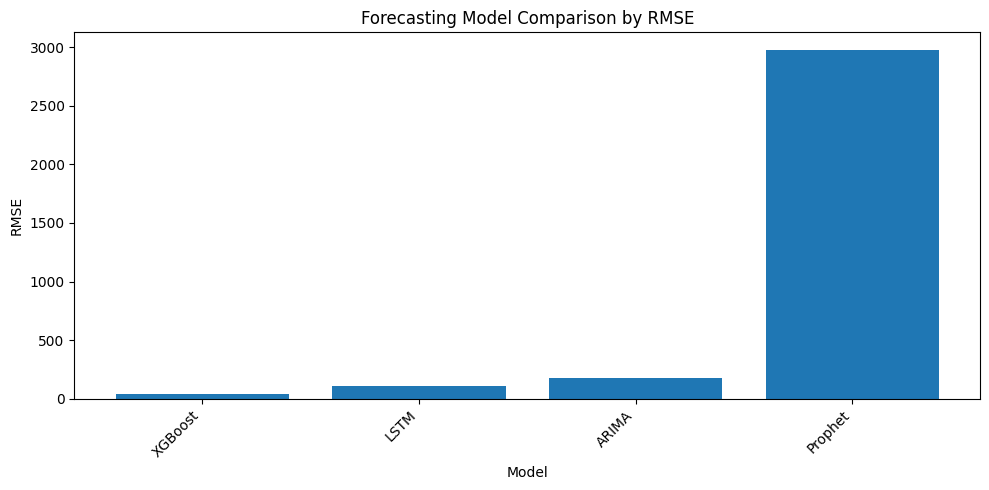

In [47]:
if not forecast_comparison.empty and "rmse" in forecast_comparison.columns:
    plot_data = forecast_comparison.dropna(subset=["rmse"]).copy()

    if not plot_data.empty:
        plt.figure(figsize=(10, 5))
        plt.bar(plot_data["model_name"], plot_data["rmse"])
        plt.title("Forecasting Model Comparison by RMSE")
        plt.xlabel("Model")
        plt.ylabel("RMSE")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "05_forecasting_model_comparison_rmse.png", dpi=300, bbox_inches="tight")
        plt.show()
    else:
        print("No RMSE values available for plotting.")
else:
    print("Forecast comparison table not available.")

## 12. Forecasting Metrics Interpretation

Use this guide to explain model results in your portfolio.

| Metric | Meaning | Better Direction |
|---|---|---|
| MAE | Average absolute prediction error | Lower |
| MSE | Average squared prediction error | Lower |
| RMSE | Error measure that penalizes large mistakes | Lower |
| MAPE | Average percentage error | Lower |
| R2 Score | How much variation is explained by the model | Higher |

In [48]:
forecast_metric_interpretation = pd.DataFrame(
    [
        {
            "metric": "MAE",
            "meaning": "Average absolute difference between actual and predicted prices.",
            "better_direction": "Lower",
        },
        {
            "metric": "MSE",
            "meaning": "Average squared difference between actual and predicted prices.",
            "better_direction": "Lower",
        },
        {
            "metric": "RMSE",
            "meaning": "Square root of MSE; penalizes large errors.",
            "better_direction": "Lower",
        },
        {
            "metric": "MAPE",
            "meaning": "Average percentage forecasting error.",
            "better_direction": "Lower",
        },
        {
            "metric": "R2 Score",
            "meaning": "Shows how much price variation the model explains.",
            "better_direction": "Higher",
        },
    ]
)

forecast_metric_interpretation

,metric,meaning,better_direction
0,MAE,Average absolute difference between actual and...,Lower
1,MSE,Average squared difference between actual and ...,Lower
2,RMSE,Square root of MSE; penalizes large errors.,Lower
3,MAPE,Average percentage forecasting error.,Lower
4,R2 Score,Shows how much price variation the model expla...,Higher


## 13. Load Forecasting Predictions

We load notebook-based prediction outputs.

Expected file:

```text
outputs/03_forecasting_predictions.csv
```

This file contains actual prices and model predictions.

In [49]:
prediction_results = notebook_predictions.copy() if notebook_predictions is not None else None

if prediction_results is not None:
    prediction_results.columns = (
        prediction_results.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )

    if "date" in prediction_results.columns:
        prediction_results["date"] = pd.to_datetime(
            prediction_results["date"],
            errors="coerce"
        )

    display(prediction_results.head())
else:
    print("Prediction results not found. Run notebook 03 first.")

,date,actual_price,asset,baseline_previous_price,baseline_rolling_mean,linear_regression_prediction,random_forest_prediction,xgboost_prediction,best_model_name
0,2023-10-04,414.1300,Stock A,422.0200,411.5843,454.9784,409.2511,419.7817,XGBoost
1,2023-10-04,145.0000,Stock A,414.1300,373.1957,304.3177,147.2329,159.1551,XGBoost
2,2023-10-05,240.0700,Bond A,402.3600,280.0614,301.0756,237.8056,242.5864,XGBoost
3,2023-10-05,66.1700,Commodity A,340.0700,282.5686,174.5903,68.5018,80.2864,XGBoost
4,2023-10-06,267.1300,Commodity A,66.1700,278.2957,367.6201,371.4593,338.6776,XGBoost


## 14. Evaluate Available Prediction Columns

This section calculates metrics for every available prediction column from notebook 03.

In [50]:
def calculate_mape(y_true, y_pred):
    """
    Calculate Mean Absolute Percentage Error.

    Args:
        y_true: Actual values.
        y_pred: Predicted values.

    Returns:
        float: MAPE percentage.
    """
    y_true_array = np.array(y_true)
    y_pred_array = np.array(y_pred)

    non_zero_mask = y_true_array != 0

    if non_zero_mask.sum() == 0:
        return 0.0

    return np.mean(
        np.abs(
            (y_true_array[non_zero_mask] - y_pred_array[non_zero_mask])
            / y_true_array[non_zero_mask]
        )
    ) * 100


def calculate_smape(y_true, y_pred):
    """
    Calculate Symmetric Mean Absolute Percentage Error.

    Args:
        y_true: Actual values.
        y_pred: Predicted values.

    Returns:
        float: SMAPE percentage.
    """
    y_true_array = np.array(y_true)
    y_pred_array = np.array(y_pred)

    denominator = (np.abs(y_true_array) + np.abs(y_pred_array)) / 2

    non_zero_mask = denominator != 0

    if non_zero_mask.sum() == 0:
        return 0.0

    return np.mean(
        np.abs(y_true_array[non_zero_mask] - y_pred_array[non_zero_mask])
        / denominator[non_zero_mask]
    ) * 100


def evaluate_prediction_column(dataframe, prediction_column):
    """
    Evaluate one prediction column.

    Args:
        dataframe (pd.DataFrame): Prediction dataframe.
        prediction_column (str): Prediction column name.

    Returns:
        dict: Metrics.
    """
    clean_data = dataframe.dropna(
        subset=["actual_price", prediction_column]
    ).copy()

    y_true = clean_data["actual_price"]
    y_pred = clean_data[prediction_column]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = calculate_mape(y_true, y_pred)
    smape = calculate_smape(y_true, y_pred)

    try:
        r2 = r2_score(y_true, y_pred)
    except Exception:
        r2 = 0.0

    return {
        "model_name": prediction_column,
        "record_count": len(clean_data),
        "mae": round(float(mae), 6),
        "mse": round(float(mse), 6),
        "rmse": round(float(rmse), 6),
        "mape": round(float(mape), 6),
        "smape": round(float(smape), 6),
        "r2_score": round(float(r2), 6),
    }


if prediction_results is not None and "actual_price" in prediction_results.columns:
    prediction_columns = [
        column for column in prediction_results.columns
        if column.endswith("_prediction")
        or column in [
            "baseline_previous_price",
            "baseline_rolling_mean",
        ]
    ]

    prediction_evaluation_rows = []

    for column in prediction_columns:
        prediction_evaluation_rows.append(
            evaluate_prediction_column(prediction_results, column)
        )

    prediction_evaluation = pd.DataFrame(prediction_evaluation_rows)
    prediction_evaluation = prediction_evaluation.sort_values("rmse").reset_index(drop=True)
    prediction_evaluation["rank"] = range(1, len(prediction_evaluation) + 1)

else:
    prediction_columns = []
    prediction_evaluation = pd.DataFrame()

prediction_evaluation

,model_name,record_count,mae,mse,rmse,mape,smape,r2_score,rank
0,xgboost_prediction,100,28.7837,1592.8248,39.9102,14.6863,12.8971,0.9179,1
1,random_forest_prediction,100,39.8683,3035.4596,55.0950,19.8053,16.1900,0.8435,2
2,linear_regression_prediction,100,82.0309,10127.2093,100.6340,43.5683,33.6384,0.4778,3
3,baseline_rolling_mean,100,109.4155,17127.1612,130.8708,72.4360,44.7038,0.1168,4
4,baseline_previous_price,100,135.9383,28538.9532,168.9348,81.9416,57.3364,-0.4717,5


## 15. Visualize Prediction Evaluation

This chart compares available prediction columns using RMSE.

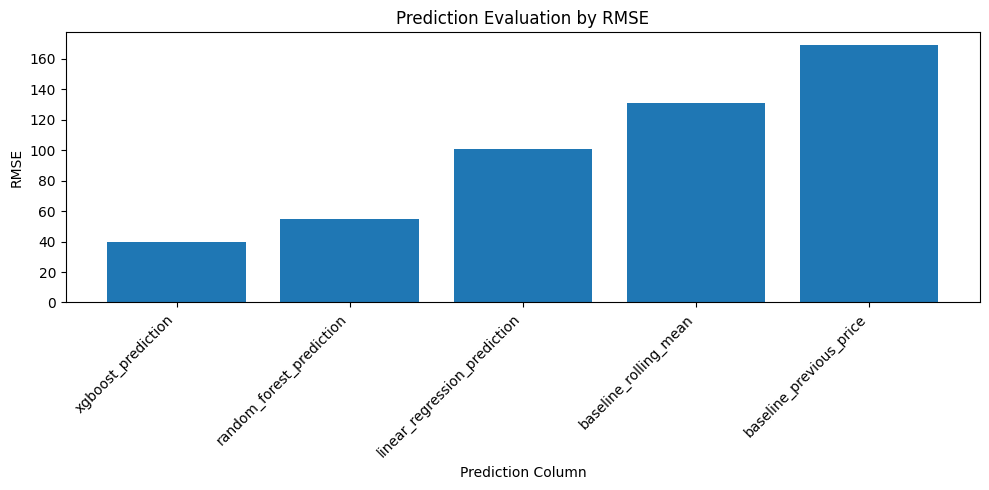

In [51]:
if not prediction_evaluation.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(prediction_evaluation["model_name"], prediction_evaluation["rmse"])
    plt.title("Prediction Evaluation by RMSE")
    plt.xlabel("Prediction Column")
    plt.ylabel("RMSE")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "05_prediction_evaluation_rmse.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No prediction evaluation available.")

## 16. Actual vs Best Prediction

We visualize actual price against the best available prediction column.

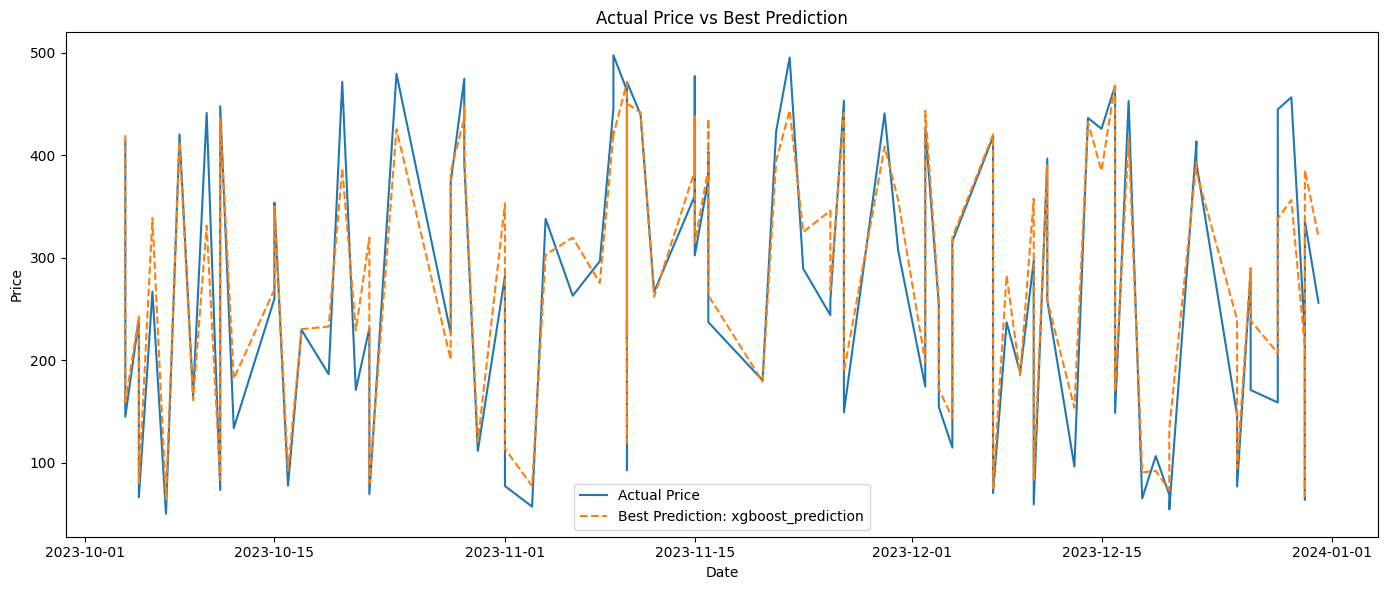

Best prediction column: xgboost_prediction


In [52]:
if prediction_results is not None and not prediction_evaluation.empty:
    best_prediction_column = prediction_evaluation.iloc[0]["model_name"]

    plot_data = prediction_results.sort_values("date").copy()

    plt.figure(figsize=(14, 6))

    plt.plot(
        plot_data["date"],
        plot_data["actual_price"],
        linewidth=1.5,
        label="Actual Price"
    )

    plt.plot(
        plot_data["date"],
        plot_data[best_prediction_column],
        linestyle="--",
        linewidth=1.5,
        label=f"Best Prediction: {best_prediction_column}"
    )

    plt.title("Actual Price vs Best Prediction")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "05_actual_vs_best_prediction.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Best prediction column:", best_prediction_column)
else:
    best_prediction_column = None
    print("Prediction results are not available.")

## 17. Asset-wise Prediction Evaluation

We evaluate the best prediction column separately for each asset.

In [53]:
if (
    prediction_results is not None
    and best_prediction_column is not None
    and "asset" in prediction_results.columns
):
    asset_prediction_metrics = []

    for asset, asset_data in prediction_results.groupby("asset"):
        clean_asset_data = asset_data.dropna(
            subset=["actual_price", best_prediction_column]
        )

        if clean_asset_data.empty:
            continue

        asset_prediction_metrics.append(
            {
                "asset": asset,
                **evaluate_prediction_column(
                    clean_asset_data,
                    best_prediction_column
                )
            }
        )

    asset_prediction_metrics_df = pd.DataFrame(asset_prediction_metrics)

else:
    asset_prediction_metrics_df = pd.DataFrame()

asset_prediction_metrics_df

,asset,model_name,record_count,mae,mse,rmse,mape,smape,r2_score
0,Bond A,xgboost_prediction,26,36.5267,2505.9200,50.0592,15.7559,14.6478,0.8849
1,Bond B,xgboost_prediction,26,28.7130,1522.4463,39.0185,16.4244,13.1433,0.9138
2,Commodity A,xgboost_prediction,22,25.6431,1297.2837,36.0178,12.4899,11.5108,0.9308
3,Stock A,xgboost_prediction,15,25.0484,1202.9650,34.6838,14.6742,12.6723,0.9392
4,Stock B,xgboost_prediction,11,22.0240,723.6584,26.9009,12.4592,11.2560,0.9576


## 18. Load Future Forecast Results

We load future forecast results from notebook 03.

Expected file:

```text
outputs/03_random_forest_future_forecast.csv
```

In [54]:
future_forecast = notebook_future_forecast.copy() if notebook_future_forecast is not None else None

if future_forecast is not None:
    future_forecast.columns = (
        future_forecast.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )

    future_forecast["date"] = pd.to_datetime(future_forecast["date"], errors="coerce")
    future_forecast["forecasted_price"] = pd.to_numeric(
        future_forecast["forecasted_price"],
        errors="coerce"
    )

    display(future_forecast.head())
else:
    print("Future forecast file not found. Run notebook 03 first.")

,date,asset,forecasted_price,model_name
0,2023-12-31,Bond A,215.8892,Random Forest
1,2024-01-01,Bond A,262.2365,Random Forest
2,2024-01-02,Bond A,361.9324,Random Forest
3,2024-01-03,Bond A,386.9119,Random Forest
4,2024-01-04,Bond A,402.8854,Random Forest


## 19. Visualize Future Forecast

This chart shows historical prices and future forecasted prices.

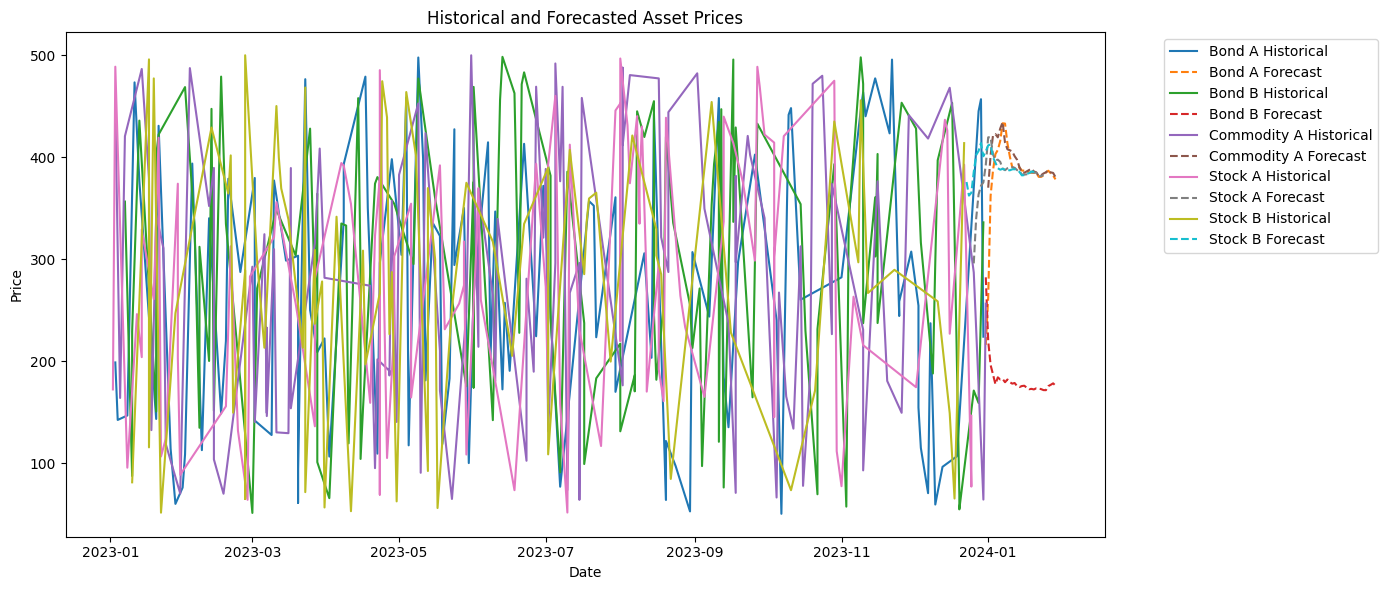

In [55]:
if future_forecast is not None and not future_forecast.empty:
    plt.figure(figsize=(14, 6))

    for asset in raw_data["asset"].unique():
        historical_asset = raw_data[raw_data["asset"] == asset].sort_values("date")
        forecast_asset = future_forecast[future_forecast["asset"] == asset].sort_values("date")

        plt.plot(
            historical_asset["date"],
            historical_asset["price"],
            linewidth=1.5,
            label=f"{asset} Historical"
        )

        if not forecast_asset.empty:
            plt.plot(
                forecast_asset["date"],
                forecast_asset["forecasted_price"],
                linestyle="--",
                linewidth=1.5,
                label=f"{asset} Forecast"
            )

    plt.title("Historical and Forecasted Asset Prices")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "05_historical_and_forecasted_prices.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Future forecast is not available.")

## 20. Load Anomaly Detection Outputs

We load anomaly outputs from notebook 04.

Important files:

```text
outputs/04_anomaly_detection_results.csv
outputs/04_full_anomaly_detection_results.csv
reports/tables/04_anomaly_summary.json
reports/tables/04_asset_anomaly_summary.csv
reports/tables/04_top_anomaly_records.csv
```

In [56]:
notebook_anomaly_results_path = OUTPUTS_DIR / "04_anomaly_detection_results.csv"
notebook_full_anomaly_results_path = OUTPUTS_DIR / "04_full_anomaly_detection_results.csv"
notebook_anomaly_summary_path = TABLES_DIR / "04_anomaly_summary.json"
notebook_asset_anomaly_summary_path = TABLES_DIR / "04_asset_anomaly_summary.csv"
notebook_top_anomaly_records_path = TABLES_DIR / "04_top_anomaly_records.csv"

anomaly_results = load_csv_if_exists(notebook_anomaly_results_path)
full_anomaly_results = load_csv_if_exists(notebook_full_anomaly_results_path)
anomaly_summary_json = load_json_if_exists(notebook_anomaly_summary_path)
asset_anomaly_summary = load_csv_if_exists(notebook_asset_anomaly_summary_path)
top_anomaly_records = load_csv_if_exists(notebook_top_anomaly_records_path)

Loaded: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\outputs\04_anomaly_detection_results.csv
Shape: (500, 13)
Loaded: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\outputs\04_full_anomaly_detection_results.csv
Shape: (500, 17)
Loaded: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\04_anomaly_summary.json
Loaded: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\04_asset_anomaly_summary.csv
Shape: (5, 11)
Loaded: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\04_top_anomaly_records.csv
Shape: (20, 17)


## 21. Fallback to Script-Based Anomaly Outputs

If notebook 04 outputs are missing, we try script-based outputs:

```text
outputs/anomaly_detection_results.csv
reports/tables/anomaly_summary.json
reports/tables/anomaly_summary.csv
reports/tables/top_anomaly_records.csv
```

In [57]:
if anomaly_results is None:
    anomaly_results = load_csv_if_exists(OUTPUTS_DIR / "anomaly_detection_results.csv")

if not anomaly_summary_json:
    anomaly_summary_json = load_json_if_exists(TABLES_DIR / "anomaly_summary.json")

if asset_anomaly_summary is None:
    asset_anomaly_summary = load_csv_if_exists(TABLES_DIR / "anomaly_summary.csv")

if top_anomaly_records is None:
    top_anomaly_records = load_csv_if_exists(TABLES_DIR / "top_anomaly_records.csv")

if anomaly_results is not None:
    anomaly_results.columns = (
        anomaly_results.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )

    if "date" in anomaly_results.columns:
        anomaly_results["date"] = pd.to_datetime(anomaly_results["date"], errors="coerce")

    display(anomaly_results.head())
else:
    print("No anomaly results available. Run notebook 04 or train_anomaly_model.py first.")

,date,asset,price,daily_return,price_z_score,is_anomaly_iqr,is_anomaly_zscore,is_anomaly_isolation_forest,anomaly_method_count,is_anomaly,anomaly_method,anomaly_severity,anomaly_score
0,2023-01-03,Bond A,198.6100,0.0000,-0.5062,False,False,False,0,False,NaN,normal,0.1163
1,2023-01-04,Bond A,142.2400,-0.2838,-0.9309,False,False,False,0,False,NaN,normal,0.1321
2,2023-01-08,Bond A,146.5800,0.0305,-0.8982,False,False,False,0,False,NaN,normal,0.0932
3,2023-01-11,Bond A,473.2000,2.2283,1.5624,False,False,False,0,False,NaN,normal,0.0080
4,2023-01-13,Bond A,376.5700,-0.2042,0.8345,False,False,False,0,False,NaN,normal,0.1192


## 22. Anomaly Detection Summary

We calculate the final anomaly detection summary.

In [58]:
if anomaly_results is not None and not anomaly_results.empty and "is_anomaly" in anomaly_results.columns:
    anomaly_results["is_anomaly"] = anomaly_results["is_anomaly"].astype(bool)

    total_records_checked = int(len(anomaly_results))
    total_anomalies = int(anomaly_results["is_anomaly"].sum())
    normal_records = total_records_checked - total_anomalies
    anomaly_rate_percent = (
        total_anomalies / total_records_checked * 100
        if total_records_checked > 0
        else 0.0
    )

    anomaly_evaluation_summary = {
        "total_records": total_records_checked,
        "normal_records": normal_records,
        "total_anomalies": total_anomalies,
        "anomaly_rate_percent": round(float(anomaly_rate_percent), 4),
        "asset_count": int(anomaly_results["asset"].nunique())
        if "asset" in anomaly_results.columns
        else None,
    }
else:
    anomaly_evaluation_summary = {
        "total_records": None,
        "normal_records": None,
        "total_anomalies": None,
        "anomaly_rate_percent": None,
        "asset_count": None,
    }

pd.DataFrame([anomaly_evaluation_summary])

,total_records,normal_records,total_anomalies,anomaly_rate_percent,asset_count
0,500,473,27,5.4000,5


## 23. Method-wise Anomaly Summary

We review how many anomalies were detected by each method.

In [59]:
if anomaly_results is not None and not anomaly_results.empty:
    method_columns = [
        "is_anomaly_iqr",
        "is_anomaly_zscore",
        "is_anomaly_isolation_forest",
    ]

    method_summary_rows = []

    for column in method_columns:
        if column in anomaly_results.columns:
            method_summary_rows.append(
                {
                    "method": column.replace("is_anomaly_", "").replace("_", " ").title(),
                    "anomaly_count": int(anomaly_results[column].astype(bool).sum()),
                }
            )

    method_summary_df = pd.DataFrame(method_summary_rows)

else:
    method_summary_df = pd.DataFrame()

method_summary_df

,method,anomaly_count
0,Iqr,0
1,Zscore,0
2,Isolation Forest,27


## 24. Visualize Method-wise Anomaly Count

This chart shows which anomaly detection method detected the most anomalies.

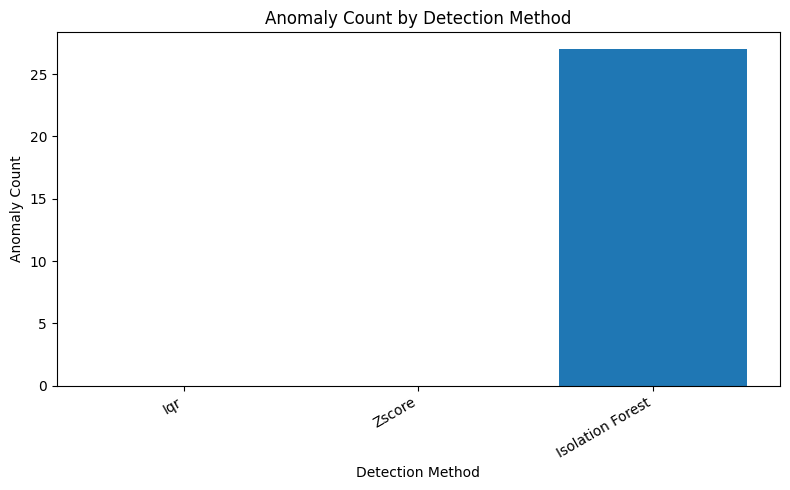

In [60]:
if not method_summary_df.empty:
    plt.figure(figsize=(8, 5))
    plt.bar(method_summary_df["method"], method_summary_df["anomaly_count"])
    plt.title("Anomaly Count by Detection Method")
    plt.xlabel("Detection Method")
    plt.ylabel("Anomaly Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "05_anomaly_method_count.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Method summary is not available.")

## 25. Asset-wise Anomaly Summary

We review which assets have the highest anomaly counts.

In [61]:
if asset_anomaly_summary is not None and not asset_anomaly_summary.empty:
    asset_anomaly_summary.columns = (
        asset_anomaly_summary.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )

    display(asset_anomaly_summary)
elif anomaly_results is not None and not anomaly_results.empty and "asset" in anomaly_results.columns:
    asset_anomaly_summary = (
        anomaly_results.groupby("asset")
        .agg(
            total_records=("is_anomaly", "count"),
            anomaly_count=("is_anomaly", "sum"),
            average_price=("price", "mean")
            if "price" in anomaly_results.columns
            else ("is_anomaly", "count"),
        )
        .reset_index()
    )

    asset_anomaly_summary["anomaly_rate_percent"] = (
        asset_anomaly_summary["anomaly_count"]
        / asset_anomaly_summary["total_records"]
        * 100
    )

    asset_anomaly_summary = asset_anomaly_summary.sort_values(
        "anomaly_count",
        ascending=False
    )

    display(asset_anomaly_summary)
else:
    asset_anomaly_summary = pd.DataFrame()
    print("Asset anomaly summary is not available.")

,asset,total_records,anomaly_count,iqr_anomaly_count,zscore_anomaly_count,isolation_forest_anomaly_count,average_price,min_price,max_price,average_anomaly_score,anomaly_rate_percent
0,Bond A,109,6,0,0,6,265.8024,50.2000,497.5900,0.0925,5.5046
1,Bond B,110,6,0,0,6,294.4699,51.0400,498.2600,0.1070,5.4545
2,Commodity A,106,6,0,0,6,280.2518,63.8600,499.7600,0.0924,5.6604
3,Stock A,101,5,0,0,5,284.8642,51.4300,496.6000,0.1181,4.9505
4,Stock B,74,4,0,0,4,281.5776,51.3000,499.7900,0.1194,5.4054


## 26. Visualize Asset-wise Anomaly Count

This chart shows which assets have the most anomaly records.

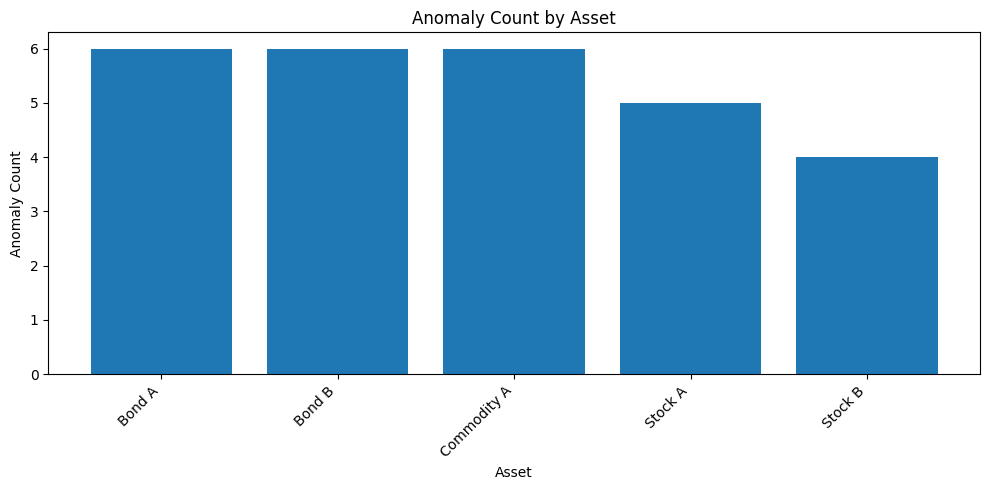

In [62]:
if not asset_anomaly_summary.empty and "anomaly_count" in asset_anomaly_summary.columns:
    plt.figure(figsize=(10, 5))
    plt.bar(asset_anomaly_summary["asset"], asset_anomaly_summary["anomaly_count"])
    plt.title("Anomaly Count by Asset")
    plt.xlabel("Asset")
    plt.ylabel("Anomaly Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "05_anomaly_count_by_asset.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Asset-wise anomaly count is not available.")

## 27. Visualize Final Anomaly Results

This chart marks final anomalies on the asset price trend.

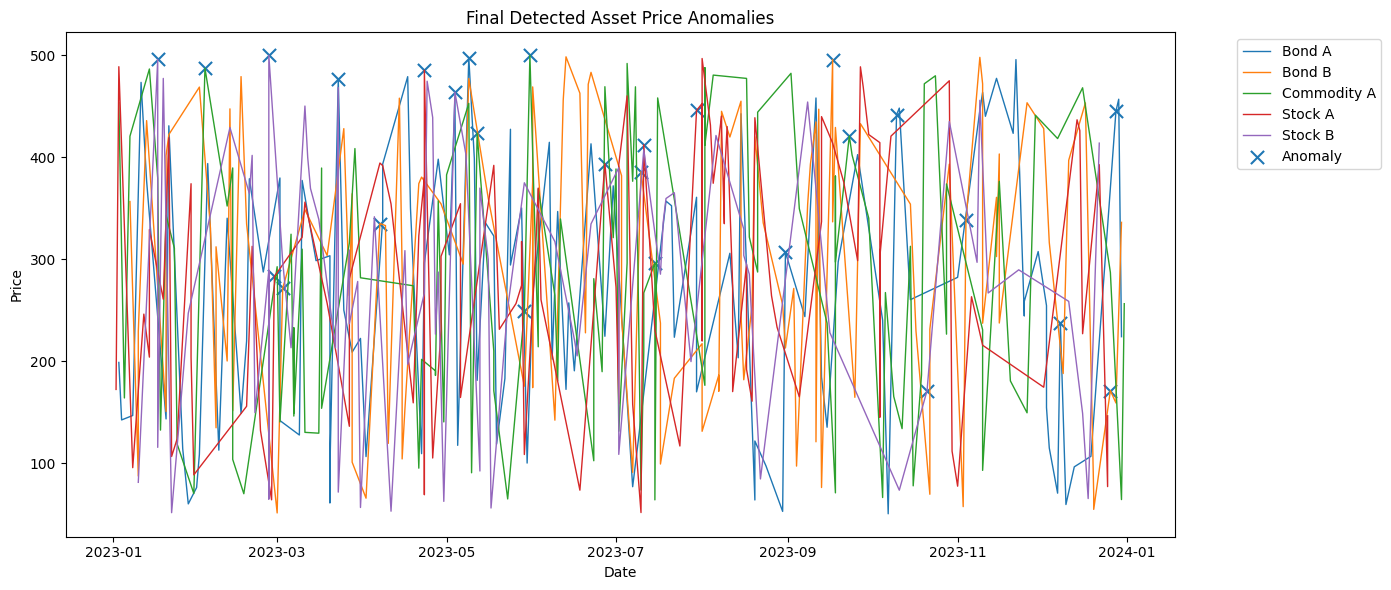

In [63]:
if anomaly_results is not None and not anomaly_results.empty and "is_anomaly" in anomaly_results.columns:
    anomaly_results["is_anomaly"] = anomaly_results["is_anomaly"].astype(bool)

    plt.figure(figsize=(14, 6))

    for asset in anomaly_results["asset"].unique():
        asset_data = anomaly_results[anomaly_results["asset"] == asset].sort_values("date")

        plt.plot(
            asset_data["date"],
            asset_data["price"],
            linewidth=1,
            label=str(asset)
        )

    anomaly_points = anomaly_results[anomaly_results["is_anomaly"]]

    if not anomaly_points.empty:
        plt.scatter(
            anomaly_points["date"],
            anomaly_points["price"],
            marker="x",
            s=90,
            label="Anomaly"
        )

    plt.title("Final Detected Asset Price Anomalies")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "05_final_anomaly_results.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Anomaly result visualization is not available.")

## 28. Top Anomaly Records

We review the most important anomaly records.

In [64]:
if top_anomaly_records is not None and not top_anomaly_records.empty:
    display(top_anomaly_records.head(20))
elif anomaly_results is not None and not anomaly_results.empty and "is_anomaly" in anomaly_results.columns:
    top_anomaly_records = anomaly_results[anomaly_results["is_anomaly"]].copy()

    sort_columns = []

    if "anomaly_method_count" in top_anomaly_records.columns:
        sort_columns.append("anomaly_method_count")

    if "anomaly_score" in top_anomaly_records.columns:
        sort_columns.append("anomaly_score")

    if sort_columns:
        ascending_values = [False if column == "anomaly_method_count" else True for column in sort_columns]
        top_anomaly_records = top_anomaly_records.sort_values(
            by=sort_columns,
            ascending=ascending_values
        )

    display(top_anomaly_records.head(20))
else:
    top_anomaly_records = pd.DataFrame()
    print("Top anomaly records are not available.")

,date,asset,price,daily_return,price_mean,price_std,zscore,is_anomaly_zscore,isolation_forest_label,is_anomaly_isolation_forest,anomaly_score,is_anomaly_iqr,anomaly_method_count,is_anomaly,anomaly_method,anomaly_severity,price_z_score
0,2023-10-10,Bond A,441.3900,7.7926,265.8024,132.7395,1.3228,False,-1,True,-0.2001,False,1,True,Isolation Forest,low,1.3228
1,2023-02-03,Commodity A,487.1900,5.9549,280.2518,133.9463,1.5449,False,-1,True,-0.1791,False,1,True,Isolation Forest,low,1.5449
2,2023-09-17,Bond B,495.5900,5.5226,294.4699,131.6930,1.5272,False,-1,True,-0.1666,False,1,True,Isolation Forest,low,1.5272
3,2023-07-11,Stock A,412.1400,7.0136,284.8642,125.3389,1.0155,False,-1,True,-0.1508,False,1,True,Isolation Forest,low,1.0155
4,2023-04-23,Stock A,485.1700,6.0284,284.8642,125.3389,1.5981,False,-1,True,-0.1354,False,1,True,Isolation Forest,low,1.5981
5,2023-08-31,Bond A,306.7900,4.8381,265.8024,132.7395,0.3088,False,-1,True,-0.1221,False,1,True,Isolation Forest,low,0.3088
6,2023-09-23,Commodity A,420.7000,4.9480,280.2518,133.9463,1.0485,False,-1,True,-0.0952,False,1,True,Isolation Forest,low,1.0485
7,2023-02-26,Stock B,499.7900,6.7271,281.5776,131.6725,1.6572,False,-1,True,-0.0855,False,1,True,Isolation Forest,low,1.6572
8,2023-03-03,Bond B,271.3700,4.3168,294.4699,131.6930,-0.1754,False,-1,True,-0.0785,False,1,True,Isolation Forest,low,-0.1754
9,2023-03-23,Bond A,476.3300,4.0560,265.8024,132.7395,1.5860,False,-1,True,-0.0771,False,1,True,Isolation Forest,low,1.5860


## 29. Severity Distribution

If anomaly severity exists, we review the severity distribution.

Severity levels:

| Level | Meaning |
|---|---|
| normal | Not detected as anomaly |
| low | Detected by one method |
| medium | Detected by two methods |
| high | Detected by three methods |

In [65]:
if anomaly_results is not None and "anomaly_severity" in anomaly_results.columns:
    severity_distribution = (
        anomaly_results["anomaly_severity"]
        .value_counts()
        .reset_index()
    )

    severity_distribution.columns = ["severity", "record_count"]

else:
    severity_distribution = pd.DataFrame()

severity_distribution

,severity,record_count
0,normal,473
1,low,27


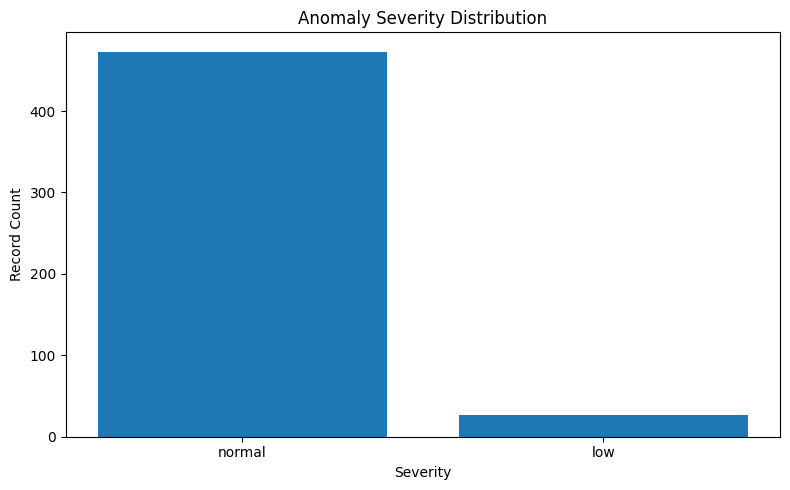

In [66]:
if not severity_distribution.empty:
    plt.figure(figsize=(8, 5))
    plt.bar(severity_distribution["severity"], severity_distribution["record_count"])
    plt.title("Anomaly Severity Distribution")
    plt.xlabel("Severity")
    plt.ylabel("Record Count")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "05_anomaly_severity_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Severity distribution is not available.")

## 30. Forecasting vs Anomaly Project Evaluation

This section combines forecasting and anomaly detection results into a single final evaluation summary.

In [67]:
final_project_evaluation = {
    "dataset": dataset_summary,
    "forecasting": {
        "comparison_source": comparison_source,
        "best_model": best_forecasting_model,
        "model_count": int(len(forecast_comparison)) if not forecast_comparison.empty else 0,
        "prediction_columns_evaluated": prediction_columns,
    },
    "anomaly_detection": anomaly_evaluation_summary,
}

final_project_evaluation

{'dataset': {'total_records': 500,
  'total_assets': 5,
  'assets': ['Bond A', 'Bond B', 'Commodity A', 'Stock A', 'Stock B'],
  'start_date': '2023-01-02 00:00:00',
  'end_date': '2023-12-31 00:00:00',
  'average_price': 281.3577,
  'minimum_price': 50.2,
  'maximum_price': 499.79},
 'forecasting': {'comparison_source': 'reports/tables/model_comparison.csv',
  'best_model': {'best_model': 'XGBoost',
   'selection_metric': 'rmse',
   'metric_value': 40.258748,
   'mae': np.float64(29.615809),
   'mape': np.float64(14.915182),
   'r2_score': np.float64(0.916421),
   'source': 'reports/tables/model_comparison.csv',
   'reason': 'Selected because it has the lowest RMSE.'},
  'model_count': 4,
  'prediction_columns_evaluated': ['baseline_previous_price',
   'baseline_rolling_mean',
   'linear_regression_prediction',
   'random_forest_prediction',
   'xgboost_prediction']},
 'anomaly_detection': {'total_records': 500,
  'normal_records': 473,
  'total_anomalies': 27,
  'anomaly_rate_percent

## 31. Final Project Strengths

This section summarizes the strengths of the project from a portfolio perspective.

In [68]:
project_strengths = [
    {
        "area": "Data Understanding",
        "strength": "The project includes dataset inspection, missing value checks, duplicate checks, and asset-level summaries.",
    },
    {
        "area": "Time Series Analysis",
        "strength": "The project analyzes trends, returns, rolling averages, and volatility.",
    },
    {
        "area": "Forecasting",
        "strength": "The project compares baseline and machine learning forecasting models using standard regression metrics.",
    },
    {
        "area": "Anomaly Detection",
        "strength": "The project combines IQR, Z-score, and Isolation Forest for robust anomaly detection.",
    },
    {
        "area": "Model Evaluation",
        "strength": "The project selects the best forecasting model using RMSE and summarizes anomaly behavior by asset.",
    },
    {
        "area": "Portfolio Readiness",
        "strength": "The project saves reusable CSV, JSON, Markdown, and figure outputs for documentation and dashboard use.",
    },
]

project_strengths_df = pd.DataFrame(project_strengths)
project_strengths_df

,area,strength
0,Data Understanding,"The project includes dataset inspection, missi..."
1,Time Series Analysis,"The project analyzes trends, returns, rolling ..."
2,Forecasting,The project compares baseline and machine lear...
3,Anomaly Detection,"The project combines IQR, Z-score, and Isolati..."
4,Model Evaluation,The project selects the best forecasting model...
5,Portfolio Readiness,"The project saves reusable CSV, JSON, Markdown..."


## 32. Business Interpretation

This project can be explained in business terms as a financial monitoring system.

It helps answer:

- Which asset prices are likely to move in the near future?
- Which forecasting model performs best?
- Which assets show unusual behavior?
- Which records should be reviewed as potential anomalies?
- Which assets may need closer risk monitoring?

In [69]:
business_interpretation = {
    "forecasting_value": (
        "Forecasting helps estimate future asset prices and supports planning, "
        "monitoring, and investment decision support."
    ),
    "anomaly_detection_value": (
        "Anomaly detection helps identify unusual asset price movements, "
        "possible data quality issues, and market behavior requiring review."
    ),
    "model_selection_value": (
        "Model comparison helps choose the most accurate forecasting model "
        "based on objective evaluation metrics."
    ),
    "risk_monitoring_value": (
        "Asset-wise anomaly summaries help identify assets with higher abnormal behavior."
    ),
}

business_interpretation

{'forecasting_value': 'Forecasting helps estimate future asset prices and supports planning, monitoring, and investment decision support.',
 'anomaly_detection_value': 'Anomaly detection helps identify unusual asset price movements, possible data quality issues, and market behavior requiring review.',
 'model_selection_value': 'Model comparison helps choose the most accurate forecasting model based on objective evaluation metrics.',
 'risk_monitoring_value': 'Asset-wise anomaly summaries help identify assets with higher abnormal behavior.'}

## 33. Save Final Evaluation Outputs

We save final evaluation outputs:

```text
reports/tables/05_final_project_evaluation.json
reports/tables/05_forecast_comparison_final.csv
reports/tables/05_prediction_evaluation.csv
reports/tables/05_asset_anomaly_summary_final.csv
reports/tables/05_project_strengths.csv
reports/final_model_evaluation_report.md
```

In [70]:
dataset_summary_df.to_csv(TABLES_DIR / "05_dataset_summary.csv", index=False)

if not forecast_comparison.empty:
    forecast_comparison.to_csv(TABLES_DIR / "05_forecast_comparison_final.csv", index=False)

if not prediction_evaluation.empty:
    prediction_evaluation.to_csv(TABLES_DIR / "05_prediction_evaluation.csv", index=False)

if not asset_prediction_metrics_df.empty:
    asset_prediction_metrics_df.to_csv(TABLES_DIR / "05_asset_prediction_metrics.csv", index=False)

if not asset_anomaly_summary.empty:
    asset_anomaly_summary.to_csv(TABLES_DIR / "05_asset_anomaly_summary_final.csv", index=False)

if not method_summary_df.empty:
    method_summary_df.to_csv(TABLES_DIR / "05_anomaly_method_summary_final.csv", index=False)

if not top_anomaly_records.empty:
    top_anomaly_records.to_csv(TABLES_DIR / "05_top_anomaly_records_final.csv", index=False)

project_strengths_df.to_csv(TABLES_DIR / "05_project_strengths.csv", index=False)

save_json(
    final_project_evaluation,
    TABLES_DIR / "05_final_project_evaluation.json"
)

print("Final evaluation outputs saved.")

Saved JSON: e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\tables\05_final_project_evaluation.json
Final evaluation outputs saved.


## 34. Generate Final Markdown Evaluation Report

This report can be used inside your project documentation.

In [71]:
report_lines = [
    "# Final Model Evaluation Report",
    "",
    "## Project",
    "",
    "Financial Portfolio Forecasting & Anomaly Detection",
    "",
    "## Dataset Summary",
    "",
    f"- Total Records: {dataset_summary.get('total_records')}",
    f"- Total Assets: {dataset_summary.get('total_assets')}",
    f"- Assets: {', '.join(dataset_summary.get('assets', []))}",
    f"- Start Date: {dataset_summary.get('start_date')}",
    f"- End Date: {dataset_summary.get('end_date')}",
    f"- Average Price: {dataset_summary.get('average_price')}",
    f"- Minimum Price: {dataset_summary.get('minimum_price')}",
    f"- Maximum Price: {dataset_summary.get('maximum_price')}",
    "",
    "## Forecasting Evaluation",
    "",
    f"- Forecast Comparison Source: {comparison_source}",
    f"- Best Forecasting Model: {best_forecasting_model.get('best_model')}",
    f"- Selection Metric: {best_forecasting_model.get('selection_metric')}",
    f"- Best Metric Value: {best_forecasting_model.get('metric_value')}",
    f"- Reason: {best_forecasting_model.get('reason')}",
    "",
    "## Forecasting Model Comparison",
    "",
    "| Model | MAE | RMSE | MAPE | R2 Score |",
    "|---|---:|---:|---:|---:|",
]

if not forecast_comparison.empty:
    for _, row in forecast_comparison.iterrows():
        report_lines.append(
            "| {model} | {mae} | {rmse} | {mape} | {r2} |".format(
                model=row.get("model_name"),
                mae=row.get("mae"),
                rmse=row.get("rmse"),
                mape=row.get("mape"),
                r2=row.get("r2_score"),
            )
        )
else:
    report_lines.append("| No forecasting comparison available | - | - | - | - |")

report_lines.extend(
    [
        "",
        "## Anomaly Detection Evaluation",
        "",
        f"- Total Records Checked: {anomaly_evaluation_summary.get('total_records')}",
        f"- Normal Records: {anomaly_evaluation_summary.get('normal_records')}",
        f"- Total Anomalies: {anomaly_evaluation_summary.get('total_anomalies')}",
        f"- Anomaly Rate: {anomaly_evaluation_summary.get('anomaly_rate_percent')}%",
        f"- Asset Count: {anomaly_evaluation_summary.get('asset_count')}",
        "",
        "## Method-wise Anomaly Summary",
        "",
        "| Method | Anomaly Count |",
        "|---|---:|",
    ]
)

if not method_summary_df.empty:
    for _, row in method_summary_df.iterrows():
        report_lines.append(
            f"| {row.get('method')} | {row.get('anomaly_count')} |"
        )
else:
    report_lines.append("| No anomaly method summary available | - |")

report_lines.extend(
    [
        "",
        "## Asset-wise Anomaly Summary",
        "",
        "| Asset | Records | Anomalies | Anomaly Rate % |",
        "|---|---:|---:|---:|",
    ]
)

if not asset_anomaly_summary.empty:
    for _, row in asset_anomaly_summary.iterrows():
        report_lines.append(
            "| {asset} | {records} | {anomalies} | {rate} |".format(
                asset=row.get("asset"),
                records=row.get("total_records"),
                anomalies=row.get("anomaly_count"),
                rate=row.get("anomaly_rate_percent"),
            )
        )
else:
    report_lines.append("| No asset anomaly summary available | - | - | - |")

report_lines.extend(
    [
        "",
        "## Business Interpretation",
        "",
        "- Forecasting helps estimate future asset price movement.",
        "- Model comparison helps identify the most accurate forecasting model.",
        "- Anomaly detection helps identify unusual asset price behavior.",
        "- Asset-wise anomaly summaries support financial risk monitoring.",
        "- Saved outputs can be used for dashboards, API responses, and portfolio documentation.",
        "",
        "## Final Recommendation",
        "",
    ]
)

if best_forecasting_model.get("best_model"):
    report_lines.append(
        f"Use **{best_forecasting_model.get('best_model')}** as the preferred forecasting model based on RMSE."
    )
else:
    report_lines.append(
        "Train forecasting models and rerun evaluation to select the best forecasting model."
    )

report_lines.extend(
    [
        "",
        "For anomaly detection, use the combined anomaly flag because it combines IQR, Z-score, and Isolation Forest methods.",
        "",
        "## Important Output Files",
        "",
        "- `reports/tables/05_final_project_evaluation.json`",
        "- `reports/tables/05_forecast_comparison_final.csv`",
        "- `reports/tables/05_prediction_evaluation.csv`",
        "- `reports/tables/05_asset_anomaly_summary_final.csv`",
        "- `reports/final_model_evaluation_report.md`",
        "- `reports/figures/05_forecasting_model_comparison_rmse.png`",
        "- `reports/figures/05_final_anomaly_results.png`",
    ]
)

final_report_path = REPORTS_DIR / "final_model_evaluation_report.md"
final_report_path.write_text("\n".join(report_lines), encoding="utf-8")

print("Final Markdown report saved at:")
print(final_report_path)

Final Markdown report saved at:
e:\VS CODE\The Developer's Arena Internship 6 months\Month 5\financial_portfolio_forecasting_anomaly_detection\reports\final_model_evaluation_report.md


## 35. Final Model Evaluation Summary

### What We Completed

In this notebook, we:

- Loaded raw project data
- Loaded forecasting experiment outputs
- Loaded anomaly detection outputs
- Compared forecasting models
- Selected the best forecasting model using RMSE
- Evaluated prediction outputs
- Reviewed anomaly detection results
- Created final evaluation charts
- Saved final evaluation tables and reports

### Key Final Outputs

```text
reports/tables/05_final_project_evaluation.json
reports/tables/05_forecast_comparison_final.csv
reports/tables/05_prediction_evaluation.csv
reports/tables/05_asset_prediction_metrics.csv
reports/tables/05_asset_anomaly_summary_final.csv
reports/tables/05_anomaly_method_summary_final.csv
reports/tables/05_top_anomaly_records_final.csv
reports/tables/05_project_strengths.csv
reports/final_model_evaluation_report.md
reports/figures/05_forecasting_model_comparison_rmse.png
reports/figures/05_prediction_evaluation_rmse.png
reports/figures/05_actual_vs_best_prediction.png
reports/figures/05_final_anomaly_results.png
```